In [25]:

# STEP 1: DATA CLEANING & VALIDATION

import pandas as pd

# Load dataset
df = pd.read_csv("C:/Users/Asus/Documents/UNIFIED/Project 1/APL_Logistics.csv", encoding='latin1') 

print("Initial Shape:", df.shape)


# Handle Missing Values

df = df.dropna(subset=[
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Delivery Status'
])


# Validate Shipping Duration

df = df[
    (df['Days for shipping (real)'] >= 0) &
    (df['Days for shipment (scheduled)'] >= 0)
]

# Remove extreme outliers
df = df[df['Days for shipping (real)'] <= 30]


# Standardize Categorical Data

df['Market'] = df['Market'].astype(str).str.strip().str.title()
df['Order Region'] = df['Order Region'].astype(str).str.strip().str.title()
df['Shipping Mode'] = df['Shipping Mode'].astype(str).str.strip().str.title()
df['Customer Segment'] = df['Customer Segment'].astype(str).str.strip().str.title()


# Remove Duplicates

df = df.drop_duplicates()


# Validate Target Variable

df = df[df['Late_delivery_risk'].isin([0, 1])]

print("After Cleaning Shape:", df.shape)



# STEP 2: DELIVERY GAP CALCULATION

# Calculate Delay Gap

df['Delay Gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']


# Classify Delivery Performance

def classify_delay(x):
    if x > 0:
        return 'Delayed'
    elif x == 0:
        return 'On-Time'
    else:
        return 'Early'

df['Delivery Performance'] = df['Delay Gap'].apply(classify_delay)


# Quick Summary

print("\nDelivery Performance Distribution:")
print(df['Delivery Performance'].value_counts())

print("\nDelay Gap Stats:")
print(df['Delay Gap'].describe())

# Preview data
df.head()

Initial Shape: (180519, 40)
After Cleaning Shape: (180519, 40)

Delivery Performance Distribution:
Delivery Performance
Delayed    103400
Early       43366
On-Time     33753
Name: count, dtype: int64

Delay Gap Stats:
count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Delay Gap, dtype: float64


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode,Delay Gap,Delivery Performance
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class,2,Delayed
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class,0,On-Time
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class,0,On-Time
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,175.99,-41.89,East Of Usa,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class,2,Delayed
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,40.00,10.00,East Of Usa,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class,2,Delayed


Total Orders: 180519
On-Time Delivery Rate (%): 42.72
Late Delivery Risk (%): 54.83
Average Delay (Days): 0.57


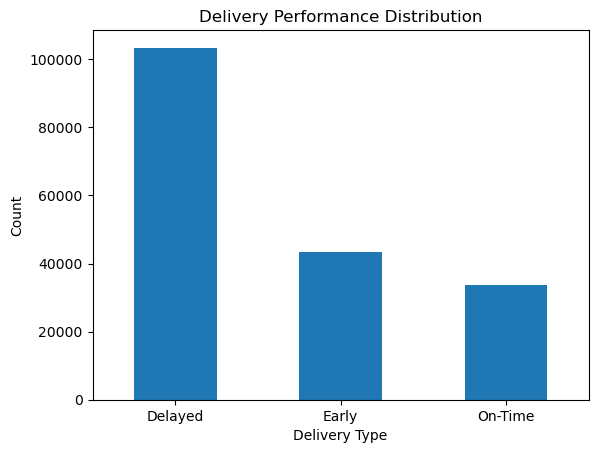

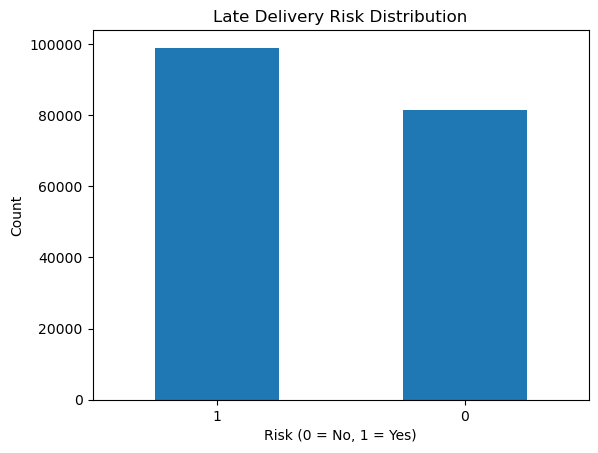

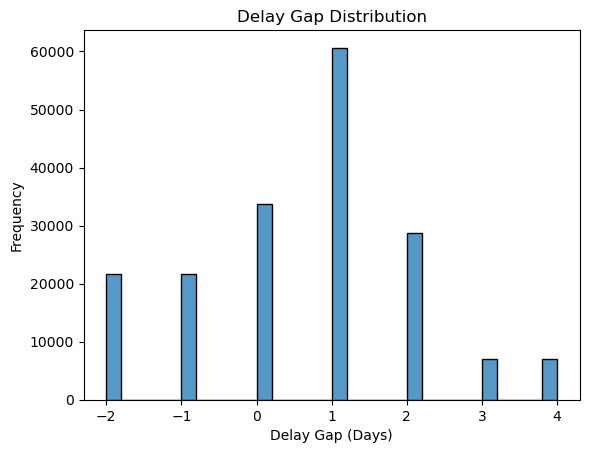

In [27]:

# Step 3 Overall Delivery Performance Analysis

import matplotlib.pyplot as plt
import seaborn as sns


# On-Time Delivery Rate

total_orders = len(df)
on_time_orders = len(df[df['Delay Gap'] <= 0])

on_time_rate = (on_time_orders / total_orders) * 100


# Late Delivery Risk Ratio

late_ratio = df['Late_delivery_risk'].mean() * 100


# Average Delay
avg_delay = df['Delay Gap'].mean()


# Print KPIs

print("Total Orders:", total_orders)
print("On-Time Delivery Rate (%):", round(on_time_rate, 2))
print("Late Delivery Risk (%):", round(late_ratio, 2))
print("Average Delay (Days):", round(avg_delay, 2))


# Distribution of Delivery Performance

plt.figure()
df['Delivery Performance'].value_counts().plot(kind='bar')
plt.title("Delivery Performance Distribution")
plt.xlabel("Delivery Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


# Late Delivery Risk Distribution

plt.figure()
df['Late_delivery_risk'].value_counts().plot(kind='bar')
plt.title("Late Delivery Risk Distribution")
plt.xlabel("Risk (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


# Delay Gap Distribution

plt.figure()
sns.histplot(df['Delay Gap'], bins=30)
plt.title("Delay Gap Distribution")
plt.xlabel("Delay Gap (Days)")
plt.ylabel("Frequency")
plt.show()

Average Delay by Shipping Mode:
Shipping Mode
Standard Class   -0.004093
Same Day          0.478279
First Class       1.000000
Second Class      1.990828
Name: Delay Gap, dtype: float64

Late Delivery Risk by Shipping Mode (%):
Shipping Mode
Standard Class    38.07
Same Day          45.74
Second Class      76.63
First Class       95.32
Name: Late_delivery_risk, dtype: float64

Order Count by Shipping Mode:
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


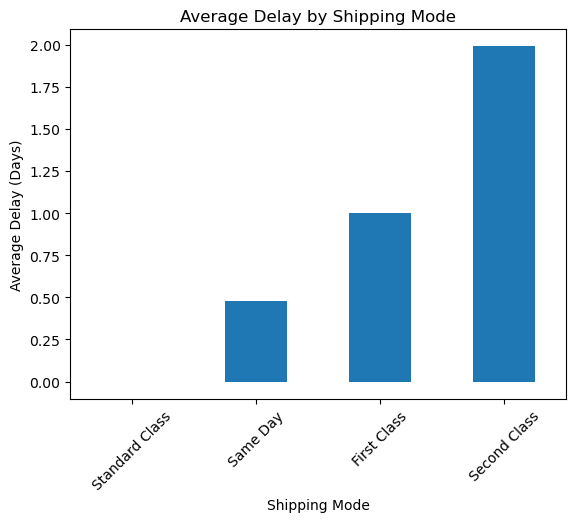

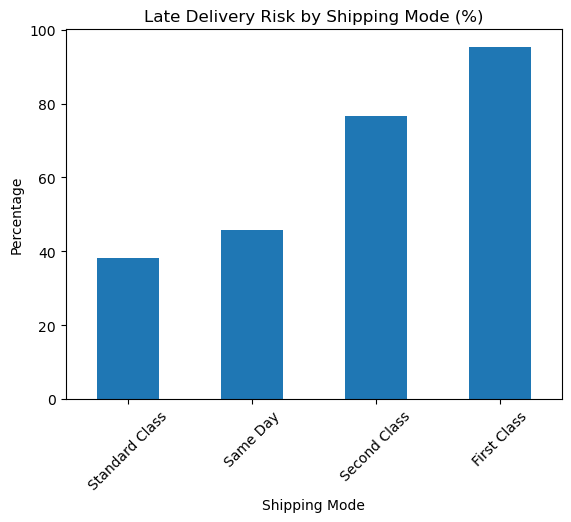

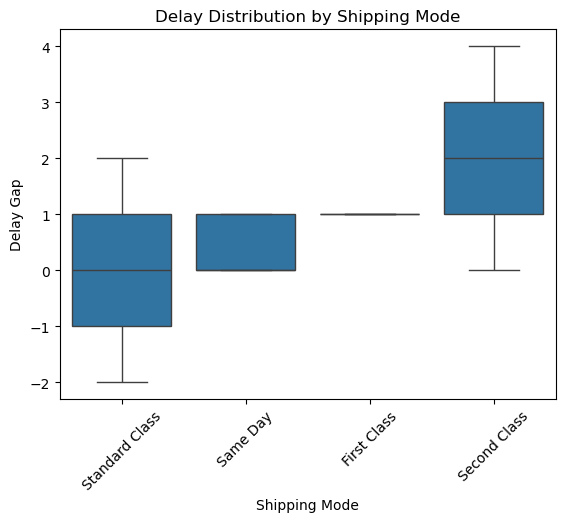

In [29]:

# Step 4 Shipping Mode Efficiency Analysis

import matplotlib.pyplot as plt
import seaborn as sns


# Average Delay by Shipping Mode

mode_delay = df.groupby('Shipping Mode')['Delay Gap'].mean().sort_values()

print("Average Delay by Shipping Mode:")
print(mode_delay)


# Late Delivery Risk by Shipping Mode

mode_risk = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values()

print("\nLate Delivery Risk by Shipping Mode (%):")
print((mode_risk * 100).round(2))


# Count of Orders by Shipping Mode

mode_count = df['Shipping Mode'].value_counts()

print("\nOrder Count by Shipping Mode:")
print(mode_count)


# Visualization: Delay by Shipping Mode

plt.figure()
mode_delay.plot(kind='bar')
plt.title("Average Delay by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=45)
plt.show()


# Visualization: Late Risk by Mode

plt.figure()
(mode_risk * 100).plot(kind='bar')
plt.title("Late Delivery Risk by Shipping Mode (%)")
plt.xlabel("Shipping Mode")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()


# Visualization: Distribution by Mode

plt.figure()
sns.boxplot(x='Shipping Mode', y='Delay Gap', data=df)
plt.title("Delay Distribution by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Delay Gap")
plt.xticks(rotation=45)
plt.show()

Average Delay by Region:
Order Region
Central Asia      0.645570
Central Africa    0.639833
South Asia        0.597465
Western Europe    0.597403
Us Center         0.587226
East Of Usa       0.584816
South Of  Usa     0.579975
Eastern Europe    0.579847
East Africa       0.570734
West Asia         0.569479
Name: Delay Gap, dtype: float64

Late Delivery Risk by Region (%):
Order Region
Central Africa    57.96
South Asia        56.27
East Africa       55.94
Western Europe    55.85
South Of  Usa     55.77
Eastern Europe    55.66
East Of Usa       55.66
Southeast Asia    55.53
Central Asia      55.33
West Asia         55.28
Name: Late_delivery_risk, dtype: float64

Average Delay by Market:
Market
Europe          0.570843
Pacific Asia    0.569365
Usca            0.568859
Africa          0.560014
Latam           0.557836
Name: Delay Gap, dtype: float64

Late Delivery Risk by Market (%):
Market
Europe          55.21
Pacific Asia    55.05
Usca            54.80
Africa          54.59
Latam      

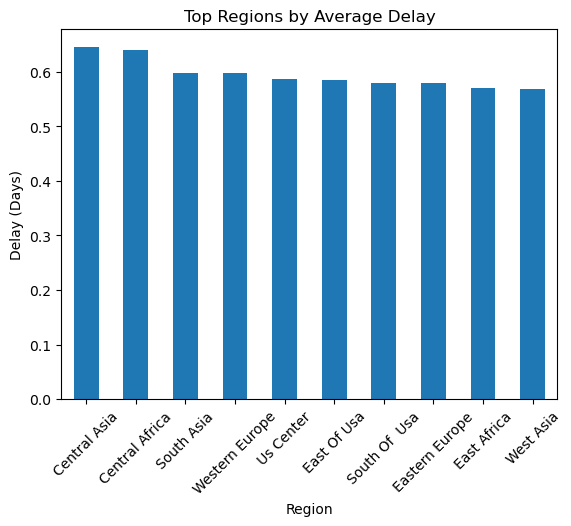

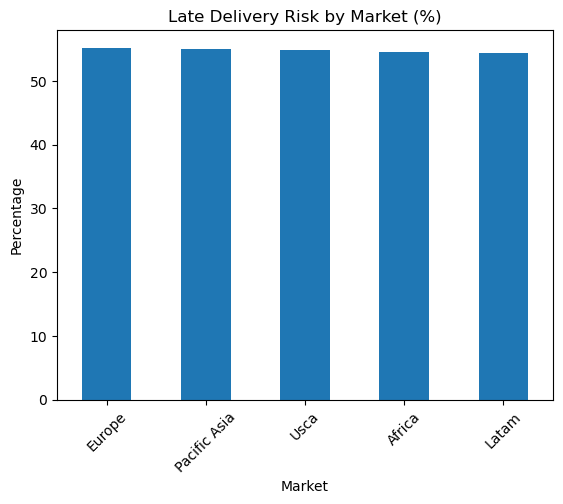

In [31]:

# Step 5 Regional and Market Diagnostics

import matplotlib.pyplot as plt


# Delay by Order Region

region_delay = df.groupby('Order Region')['Delay Gap'].mean().sort_values(ascending=False)

print("Average Delay by Region:")
print(region_delay.head(10))


# Late Delivery Risk by Region

region_risk = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False)

print("\nLate Delivery Risk by Region (%):")
print((region_risk * 100).round(2).head(10))


# Delay by Market

market_delay = df.groupby('Market')['Delay Gap'].mean().sort_values(ascending=False)

print("\nAverage Delay by Market:")
print(market_delay)


# Late Delivery Risk by Market

market_risk = df.groupby('Market')['Late_delivery_risk'].mean().sort_values(ascending=False)

print("\nLate Delivery Risk by Market (%):")
print((market_risk * 100).round(2))


# Top 10 Countries with Highest Delay

country_delay = df.groupby('Order Country')['Delay Gap'].mean().sort_values(ascending=False).head(10)

print("\nTop 10 Countries by Delay:")
print(country_delay)


# Visualization: Region Delay

plt.figure()
region_delay.head(10).plot(kind='bar')
plt.title("Top Regions by Average Delay")
plt.xlabel("Region")
plt.ylabel("Delay (Days)")
plt.xticks(rotation=45)
plt.show()


# Visualization: Market Risk

plt.figure()
(market_risk * 100).plot(kind='bar')
plt.title("Late Delivery Risk by Market (%)")
plt.xlabel("Market")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

Average Delay by Customer Segment:
Customer Segment
Home Office    0.577949
Consumer       0.564917
Corporate      0.560185
Name: Delay Gap, dtype: float64

Late Delivery Risk by Customer Segment (%):
Customer Segment
Home Office    55.07
Consumer       54.81
Corporate      54.72
Name: Late_delivery_risk, dtype: float64

Order Count by Customer Segment:
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64


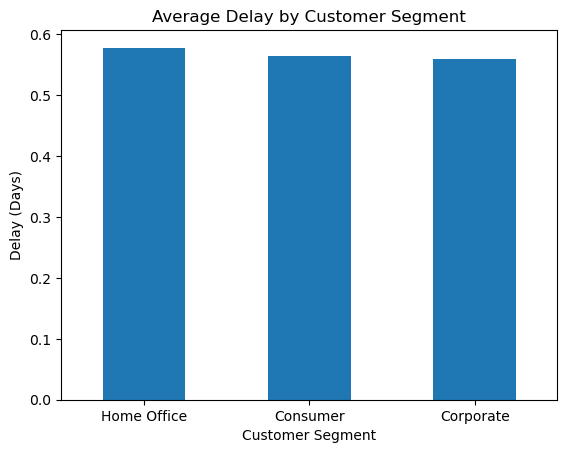

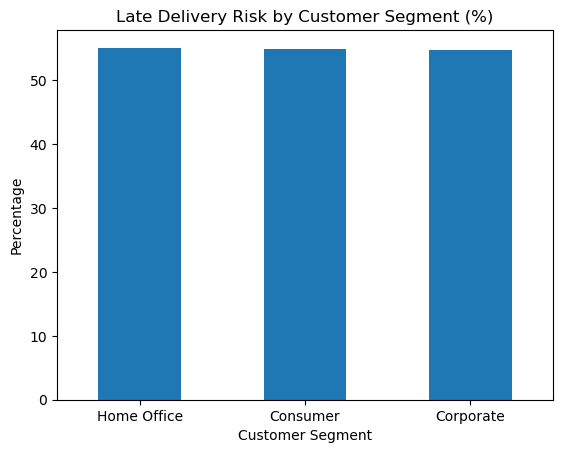

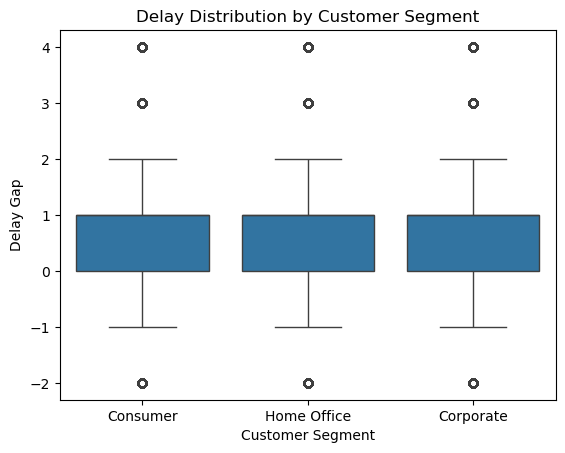

In [33]:

# Step 6 Customer Segment Impact Analysis


import matplotlib.pyplot as plt
import seaborn as sns


# Average Delay by Customer Segment

segment_delay = df.groupby('Customer Segment')['Delay Gap'].mean().sort_values(ascending=False)

print("Average Delay by Customer Segment:")
print(segment_delay)


# Late Delivery Risk by Segment

segment_risk = df.groupby('Customer Segment')['Late_delivery_risk'].mean().sort_values(ascending=False)

print("\nLate Delivery Risk by Customer Segment (%):")
print((segment_risk * 100).round(2))


# Order Volume by Segment

segment_count = df['Customer Segment'].value_counts()

print("\nOrder Count by Customer Segment:")
print(segment_count)


# Visualization: Delay by Segment

plt.figure()
segment_delay.plot(kind='bar')
plt.title("Average Delay by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Delay (Days)")
plt.xticks(rotation=0)
plt.show()


# Visualization: Risk by Segment

plt.figure()
(segment_risk * 100).plot(kind='bar')
plt.title("Late Delivery Risk by Customer Segment (%)")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()


# Visualization: Distribution

plt.figure()
sns.boxplot(x='Customer Segment', y='Delay Gap', data=df)
plt.title("Delay Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Delay Gap")
plt.show()

In [35]:

# KPI Summary Table


import pandas as pd

# KPIs
total_orders = len(df)
on_time_rate = (len(df[df['Delay Gap'] <= 0]) / total_orders) * 100
late_risk = df['Late_delivery_risk'].mean() * 100
avg_delay = df['Delay Gap'].mean()

# Shipping Mode Efficiency (difference from best)
mode_efficiency = df.groupby('Shipping Mode')['Delay Gap'].mean()
best_mode = mode_efficiency.min()
efficiency_index = (mode_efficiency - best_mode).round(3)

# Regional Delay Index (top region delay)
region_delay = df.groupby('Order Region')['Delay Gap'].mean().max()

# Create KPI table
kpi_df = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "On-Time Delivery Rate (%)",
        "Late Delivery Risk (%)",
        "Average Delivery Delay (Days)",
        "Best Shipping Mode (Lowest Delay)",
        "Worst Shipping Mode (Highest Delay)",
        "Max Regional Delay (Days)"
    ],
    "Value": [
        total_orders,
        round(on_time_rate, 2),
        round(late_risk, 2),
        round(avg_delay, 2),
        mode_efficiency.idxmin(),
        mode_efficiency.idxmax(),
        round(region_delay, 2)
    ]
})

kpi_df

,KPI,Value
0,Total Orders,180519
1,On-Time Delivery Rate (%),42.72
2,Late Delivery Risk (%),54.83
3,Average Delivery Delay (Days),0.57
4,Best Shipping Mode (Lowest Delay),Standard Class
5,Worst Shipping Mode (Highest Delay),Second Class
6,Max Regional Delay (Days),0.65


In [37]:
df.to_csv("cleaned_logistics.csv", index=False)